In [1]:
import torch
from PIL import Image
%cd nanoVLM

from models.vision_language_model_action import VisionLanguageActionModel
import models.config as config
from data.emptyenv_action_dataset import DEFAULT_PROMPT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# загружаем конфиг
vlm_cfg = config.VLMConfig()

# загружаем модель
#model = VisionLanguageActionModel(vlm_cfg, load_backbone=True, num_actions=3)
model = VisionLanguageActionModel.from_pretrained("/teamspace/studios/this_studio/nanoVLM/checkpoints_emptyenv_action/step_500_1.0")

model.to(device)
model.eval()

print("Model loaded.")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/teamspace/studios/this_studio/nanoVLM
Model loaded.


In [2]:
import json
import os

dataset_root = "/teamspace/studios/this_studio/nanoVLM/data/emptyenv_sft_dataset"
jsonl_path = os.path.join(dataset_root, "dataset.jsonl")

with open(jsonl_path, "r") as f:
    lines = f.readlines()

sample = json.loads(lines[10])   # любой индекс
img_path = os.path.join(dataset_root, sample["image"])
true_action = sample["action"]

print("True action:", true_action)

True action: forward


In [5]:
from data.emptyenv_action_dataset import EmptyEnvActionDataset, DEFAULT_PROMPT
from data.action_collator import ActionCollator
from torch.utils.data import DataLoader

vlm_cfg.max_img_size = 512
full_ds = EmptyEnvActionDataset(
    jsonl_path=jsonl_path,
    images_root=dataset_root,
    vlm_cfg=vlm_cfg,
    prompt=DEFAULT_PROMPT,
    max_samples = 20_000
) 

collator = ActionCollator(model.tokenizer, max_length=4096)
train_loader = DataLoader(full_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=False, collate_fn=collator, drop_last=True)

Resize to max side len: True


torch.Size([107])
<|im_start|>user
<|global_image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|>You are controlling an agent in a grid world. Choose the next action to reach the green goal. Valid actions: left, right, forward. Answer with the best next action.<|im_end|>



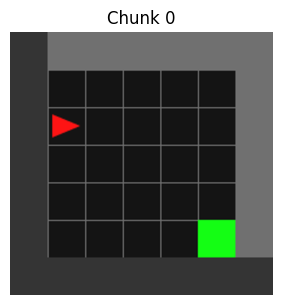

In [23]:
import math
import matplotlib.pyplot as plt

sample = full_ds[3142]
imgs = sample["images"][0]

ids = sample["input_ids"]
print(ids.shape)

text = model.tokenizer.decode(ids, skip_special_tokens=False)
print(text)

n = len(imgs)
cols = 5
rows = math.ceil(n / cols)

plt.figure(figsize=(3*cols, 3*rows))

for i in range(n):
    plt.subplot(rows, cols, i+1)
    img_np = imgs[i].permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-6)
    plt.imshow(img_np)
    plt.title(f"Chunk {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# testing with dataloader

batch = next(iter(train_loader))

print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["action_label"].shape)

model.eval()

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
images = batch["images"]
labels = batch["action_label"].to(device)

with torch.no_grad():
    logits, loss = model(
        input_ids=input_ids,
        images=images,
        attention_mask=attention_mask,
        action_labels=labels
    )

print("Loss:", loss.item())
print("Logits shape:", logits.shape)

probs = torch.softmax(logits, dim=-1)
preds = torch.argmax(probs, dim=-1)

print("Preds:", preds[:10])
print("Labels:", labels[:10])

acc = (preds == labels).float().mean()
print("Batch accuracy:", acc.item()) 

input_ids shape: torch.Size([16, 107])
attention_mask shape: torch.Size([16, 107])
labels shape: torch.Size([16])


Loss: 4.99188672620221e-07
Logits shape: torch.Size([16, 3])
Preds: tensor([1, 2, 2, 2, 0, 0, 0, 2, 2, 2], device='cuda:0')
Labels: tensor([1, 2, 2, 2, 0, 0, 0, 2, 2, 2], device='cuda:0')
Batch accuracy: 1.0


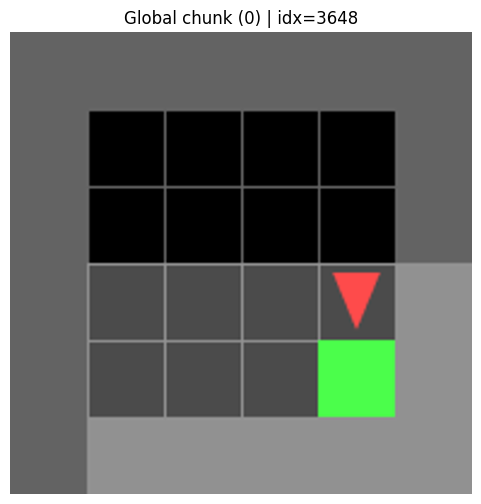

idx=3648
Tgt:   forward
Pred: forward
Probs: left=0.000 right=0.000 forward=1.000
--------------------------------------------------


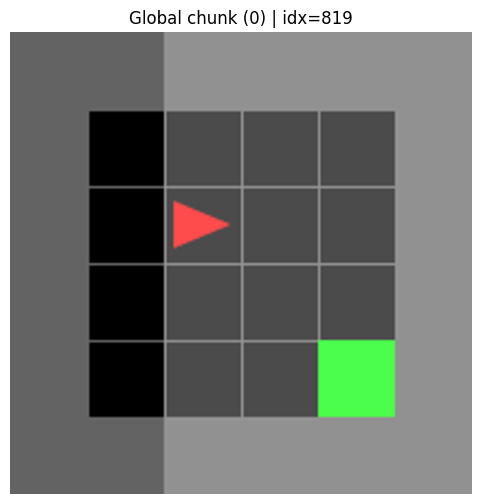

idx=819
Tgt:   forward
Pred: forward
Probs: left=0.000 right=0.000 forward=1.000
--------------------------------------------------


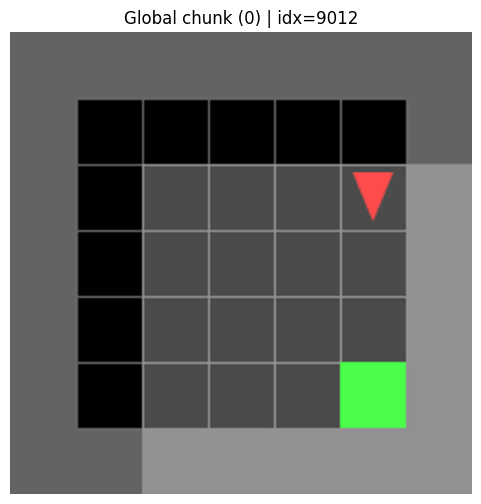

idx=9012
Tgt:   forward
Pred: forward
Probs: left=0.000 right=0.000 forward=1.000
--------------------------------------------------


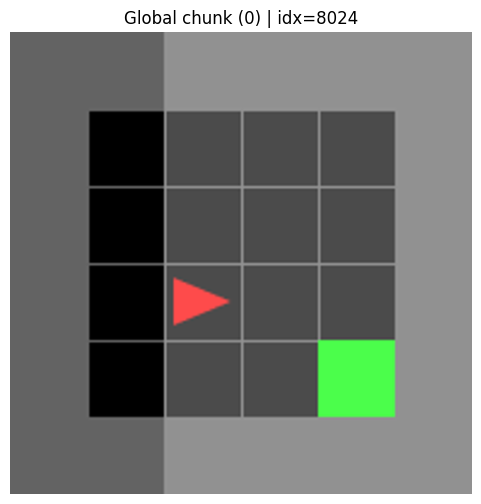

idx=8024
Tgt:   forward
Pred: forward
Probs: left=0.000 right=0.000 forward=1.000
--------------------------------------------------


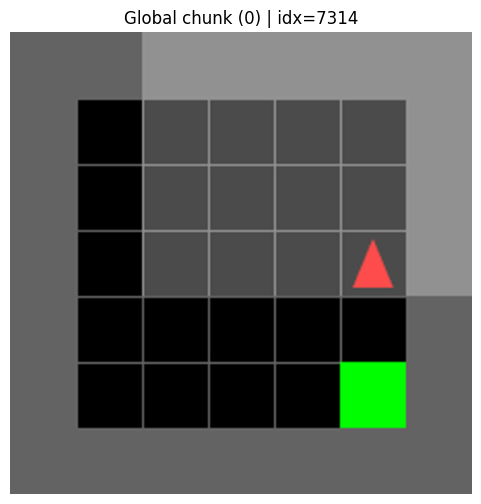

idx=7314
Tgt:   left
Pred: left
Probs: left=1.000 right=0.000 forward=0.000
--------------------------------------------------


In [22]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

ID2ACTION = {0: "left", 1: "right", 2: "forward"}

def show_tensor_img(t):
    # t: [3,H,W] torch tensor (likely normalized)
    img = t.detach().cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
    plt.imshow(img)
    plt.axis("off")

@torch.no_grad()
def infer_one(sample):
    # sample from EmptyEnvActionDataset: dict with images/input_ids/attention_mask/action_label
    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    images = [sample["images"]]  # batch of size 1, keep list structure

    logits, _ = model(
        input_ids=input_ids,
        images=images,
        attention_mask=attention_mask,
        action_labels=None
    )
    probs = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
    pred_id = int(np.argmax(probs))
    return pred_id, probs

def show_5_examples(ds, indices=None, show_all_chunks=False, seed=0):
    random.seed(seed)
    if indices is None:
        indices = random.sample(range(len(ds)), 5)

    for idx in indices:
        sample = ds[idx]
        true_id = int(sample["action_label"].item())
        pred_id, probs = infer_one(sample)

        # --- visualization ---
        imgs = sample["images"][0]  # list of chunks (tensors)
        plt.figure(figsize=(6, 6))

        if show_all_chunks:
            # show grid of all chunks
            n = len(imgs)
            cols = 5
            rows = int(np.ceil(n / cols))
            plt.figure(figsize=(3*cols, 3*rows))
            for i in range(n):
                plt.subplot(rows, cols, i+1)
                show_tensor_img(imgs[i])
                plt.title(f"Chunk {i}", fontsize=10)
            plt.tight_layout()
            plt.show()
        else:
            # show only global chunk (usually 0)
            show_tensor_img(imgs[0])
            plt.title(f"Global chunk (0) | idx={idx}", fontsize=12)
            plt.show()

        print(f"idx={idx}")
        print(f"Tgt:   {ID2ACTION[true_id]}")
        print(f"Pred: {ID2ACTION[pred_id]}")
        print(f"Probs: left={probs[0]:.3f} right={probs[1]:.3f} forward={probs[2]:.3f}")
        print("-" * 50)

# Запуск:
show_5_examples(full_ds, show_all_chunks=False, seed=42)